# Notebook 1 · Quantum Foundations for AI Practitioners
### SDS2026 Workshop — *Quantum AI: From Inspiration to Enhancement - A Practical Journey*

---

**Goal.** Build intuition for quantum states as vectors, multi-qubit tensor products, gates, and runnable circuits in Qiskit and PennyLane.

| Section | Topic |
|---------|-------|
| Part 0 | Computational basis, Dirac ↔ column vectors, normalization |
| Part 0 | Multi-qubit tensor products and basis ordering |
| 1 | Why quantum computing for AI |
| 2 | Qubits, superposition, entanglement |
| 3 | Quantum gates and circuits |
| 4 | Setup |
| 5 | Hands-on: Qiskit circuits |
| 6 | Hands-on: PennyLane and quantum gradients |
| 7 | Variational quantum circuit (VQC) training |

## Reading guide

This notebook uses very small circuits so that every object has an intuitive meaning. A qubit starts in $\lvert 0 \rangle$ by default; preparing $\lvert 1 \rangle$ means applying $X$ first, or using state-preparation routines in software. Gates rotate or correlate qubits. Measurement turns the quantum state into classical bits. Notebook 2 starts with a separate prerequisite mini-lab on data encoding for hybrid models.

---
## Part 0 · Skills you need (and where they go)

The table below maps tasks in this workshop to the background you should recognize. If a row is unfamiliar, work through the subsection that follows before skipping ahead.

| If you want to… | You should be comfortable with… | Developed in… |
|-------------------|----------------------------------|----------------|
| Read $\lvert 0 \rangle$, $\lvert 1 \rangle$ as vectors | Column vectors, complex conjugate for bras, $\lvert \alpha \rvert^2$ as probability | §0.1 |
| Understand $\lvert 00 \rangle$, $\lvert 11 \rangle$ labels | Tensor (Kronecker) product, ordering of qubits | §0.2 |
| Run code | NumPy vectors, basic Python; optional: Qiskit `QuantumCircuit` | §4 onward |

*Libraries:* Qiskit $\geq$ 2.2 where available, PennyLane $\geq$ 0.44, NumPy, Matplotlib.

### §0.1 Computational basis as column vectors

A pure single-qubit state is a complex column vector with Euclidean norm 1. The computational basis is

$$
\lvert 0 \rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \qquad
\lvert 1 \rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}.
$$

A general state $\lvert \psi \rangle = \alpha \lvert 0 \rangle + \beta \lvert 1 \rangle$ has the column form

$$
\lvert \psi \rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}, \qquad
\lvert \alpha \rvert^2 + \lvert \beta \rvert^2 = 1.
$$

Measuring in the computational basis gives outcome $k \in \{0,1\}$ with probability $\lvert \langle k \mid \psi \rangle \rvert^2$, i.e. $\lvert \alpha \rvert^2$ for 0 and $\lvert \beta \rvert^2$ for 1. Global phase $e^{i\chi}\lvert \psi \rangle$ does not change those probabilities.

In [1]:
import numpy as np

ket0 = np.array([1.0, 0.0], dtype=complex)
ket1 = np.array([0.0, 1.0], dtype=complex)

alpha = 1 / np.sqrt(3)
beta = np.sqrt(2 / 3) * np.exp(1j * np.pi / 4)
psi = alpha * ket0 + beta * ket1

print("|0> as column:", ket0)
print("|1> as column:", ket1)
print("|psi> =", np.round(psi, 4))
print("norm", np.linalg.norm(psi))
print("P(0)=", np.abs(alpha) ** 2, " P(1)=", np.abs(beta) ** 2)


|0> as column: [1.+0.j 0.+0.j]
|1> as column: [0.+0.j 1.+0.j]
|psi> = [0.5774+0.j     0.5774+0.5774j]
norm 1.0
P(0)= 0.3333333333333334  P(1)= 0.6666666666666669


### §0.2 Multiple qubits: tensor products and basis ordering

For two qubits, the Hilbert space dimension is $2 \times 2 = 4$. Basis states are tensor products, written $\lvert q_1 q_0 \rangle$ in circuit notation. Qiskit uses a *little-endian* convention: in the bitstring, $q_0$ is the rightmost bit, and an amplitude index $j \in \{0,1,2,3\}$ corresponds to the binary digits of $q_1 q_0$.

$$
\lvert 00 \rangle = \lvert 0 \rangle \otimes \lvert 0 \rangle, \quad
\lvert 01 \rangle = \lvert 0 \rangle \otimes \lvert 1 \rangle, \quad
\lvert 10 \rangle = \lvert 1 \rangle \otimes \lvert 0 \rangle, \quad
\lvert 11 \rangle = \lvert 1 \rangle \otimes \lvert 1 \rangle.
$$

In NumPy, use `np.kron` for $\otimes$. The computational-basis ordering for amplitudes is $\lvert 00 \rangle, \lvert 01 \rangle, \lvert 10 \rangle, \lvert 11 \rangle$ matching indices $0,1,2,3$.

In [2]:
ket00 = np.kron(ket0, ket0)
ket11 = np.kron(ket1, ket1)
print("|00> coeff vector (indices 0..3):", ket00)
print("|11> coeff vector:", ket11)

bell = (ket00 + ket11) / np.sqrt(2)
print("Bell |Phi+>:", np.round(bell, 4))
print("norm", np.linalg.norm(bell))


|00> coeff vector (indices 0..3): [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|11> coeff vector: [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
Bell |Phi+>: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
norm 0.9999999999999999


---
## 1. Why Quantum Computing for AI?

Quantum computing is **not** about replacing classical computers — it targets specific classes of problems where classical methods scale poorly. Several acronyms appear repeatedly in this and later notebooks:

- **QAOA** (Quantum Approximate Optimization Algorithm): a parameterized quantum circuit + classical optimizer pair, used for combinatorial problems formulated as Ising / QUBO Hamiltonians.
- **VQE** (Variational Quantum Eigensolver): same hybrid pattern, used to estimate ground-state energies of molecular or condensed-matter Hamiltonians.
- **VQC** (Variational Quantum Circuit): a generic parameterized quantum circuit trained against a cost function (umbrella term that includes QAOA and VQE).
- **MCMC** (Markov-Chain Monte Carlo): classical sampling baseline often compared against quantum samplers.
- **MPS** (Matrix Product State): a tensor-network representation that compresses certain quantum states and is widely used in quantum-inspired classical methods.

| Problem Class | Classical baseline | Where quantum is studied |
|---|---|---|
| Combinatorial optimization | Heuristics, branch & bound | QAOA, quantum annealing |
| Sampling complex distributions | MCMC (slow mixing) | Quantum sampling |
| Chemistry simulation | Exponential memory in $n$ | VQE (polynomial-depth ansätze) |
| Kernel methods | $O(n^2)$ feature maps | Exponentially large Hilbert spaces |

**Timeline note.** Fault-tolerant advantage for generic machine learning is several years away. Near-term value lives in *hybrid* (quantum + classical) algorithms and in *quantum-inspired* methods (tensor networks, MPS).

---
## 2. Qubits, Superposition & Entanglement

### Qubit state

$$\lvert \psi \rangle = \alpha \lvert 0 \rangle + \beta \lvert 1 \rangle, \qquad \lvert \alpha \rvert^2 + \lvert \beta \rvert^2 = 1.$$

$\lvert \alpha \rvert^2$ is the probability of measuring 0; $\lvert \beta \rvert^2$ for 1.

### Superposition

A qubit is described by a complex linear combination of $\lvert 0 \rangle$ and $\lvert 1 \rangle$ until it is measured. The Hadamard gate ($H$) creates an equal superposition:

$$H \lvert 0 \rangle = \tfrac{1}{\sqrt{2}}\!\left(\lvert 0 \rangle + \lvert 1 \rangle\right) \equiv \lvert + \rangle.$$

### Entanglement

Two qubits can be in a state that is *not* a tensor product of single-qubit states; their measurement outcomes become correlated. The canonical example is the Bell state

$$\lvert \Phi^+ \rangle = \tfrac{1}{\sqrt{2}}\!\left(\lvert 00 \rangle + \lvert 11 \rangle\right).$$

### Why it matters for ML

An $n$-qubit system lives in a $2^n$-dimensional Hilbert space. A 50-qubit system spans $2^{50} \approx 10^{15}$ dimensions — far more than any classical feature map can store explicitly.

---
## 3. Quantum Gates

| Gate | Matrix | Effect |
|------|--------|--------|
| Hadamard (H) | $\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | Superposition |
| Pauli-X | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | Bit flip |
| Pauli-Z | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | Phase flip |
| CNOT | $\begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$ | Entangle two qubits |
| RY(θ) | $\begin{pmatrix}\cos\frac{\theta}{2}&-\sin\frac{\theta}{2}\\\sin\frac{\theta}{2}&\cos\frac{\theta}{2}\end{pmatrix}$ | Rotation (trainable) |

---
## 4. Setup

In [3]:
# Run once before the workshop
import subprocess, sys

packages = [
    'pennylane>=0.38.0',
    'qiskit>=1.2.0',
    'qiskit-aer>=0.14.0',
    'matplotlib',
    'numpy',
    'scipy',
    'torch>=2.0.0',
    'tensorly>=0.8.0',
    'scikit-learn>=1.4.0',
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed!')

All packages installed!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

print(f'PennyLane: {qml.__version__}')
import qiskit
print(f'Qiskit:    {qiskit.__version__}')
print('Imports OK')

PennyLane: 0.44.0
Qiskit:    2.2.0
Imports OK


---
## 5. Hands-On: Qiskit Circuits

### 5a. Bell state — two-qubit entanglement

$$\lvert \Phi^+ \rangle = \frac{\lvert 00 \rangle + \lvert 11 \rangle}{\sqrt{2}}.$$

Construction: the Hadamard gate ($H$) puts qubit 0 into $\lvert + \rangle$, and the controlled-NOT (CNOT) entangles qubit 1 with qubit 0. CNOT acts as $\lvert a \rangle \lvert b \rangle \mapsto \lvert a \rangle \lvert a \oplus b \rangle$ where $a$ is the control and $\oplus$ is XOR.

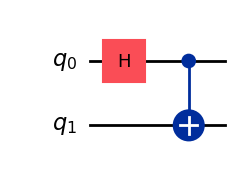

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Measurement counts: {'00': 499, '11': 525}


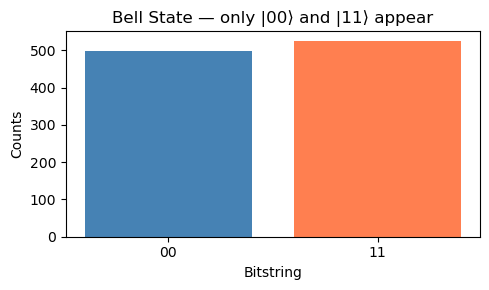

In [5]:
# ── Bell State ───────────────────────────────────────────────────────────
from IPython.display import display

qc_unitary = QuantumCircuit(2)
qc_unitary.h(0)
qc_unitary.cx(0, 1)
try:
    display(qc_unitary.draw(output="mpl", fold=-1))
except Exception as exc:
    print("mpl:", exc)
    print(qc_unitary.draw(output="text"))

qc = QuantumCircuit(2, 2)
qc.h(0)       # Hadamard: |0⟩ → (|0⟩+|1⟩)/√2
qc.cx(0, 1)   # CNOT: entangle qubit 1 with qubit 0
qc.measure([0, 1], [0, 1])

print(qc.draw(output='text'))

sim = AerSimulator()
job = sim.run(qc, shots=1024)
counts = job.result().get_counts()
print('\nMeasurement counts:', counts)

# Visualise
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.keys(), counts.values(), color=['steelblue','coral'])
ax.set_title('Bell State — only |00⟩ and |11⟩ appear')
ax.set_xlabel('Bitstring'); ax.set_ylabel('Counts')
plt.tight_layout(); plt.savefig('bell_state.png', dpi=80); plt.show()

### 5b. GHZ state — three-qubit entanglement

The Greenberger–Horne–Zeilinger (**GHZ**) state generalizes the Bell state to three qubits:

$$\lvert \mathrm{GHZ} \rangle = \frac{\lvert 000 \rangle + \lvert 111 \rangle}{\sqrt{2}}.$$

Construction: $H$ on qubit 0, then CNOT from qubit 0 to qubits 1 and 2.

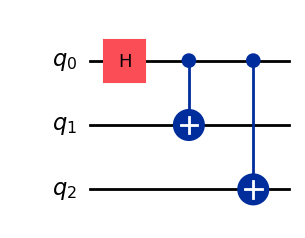

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 
Counts: {'000': 525, '111': 499}


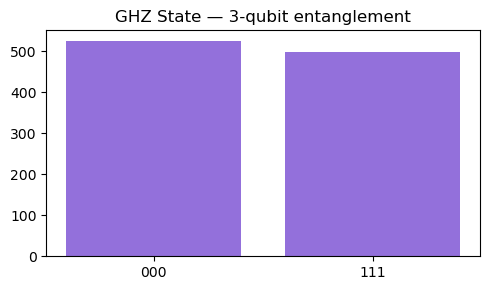

In [6]:
from IPython.display import display

qc_ghz_u = QuantumCircuit(3)
qc_ghz_u.h(0)
qc_ghz_u.cx(0, 1)
qc_ghz_u.cx(0, 2)
try:
    display(qc_ghz_u.draw(output="mpl", fold=-1))
except Exception as exc:
    print("mpl:", exc)
    print(qc_ghz_u.draw(output="text"))

qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)
qc_ghz.measure([0,1,2],[0,1,2])

print(qc_ghz.draw(output='text'))

counts_ghz = sim.run(qc_ghz, shots=1024).result().get_counts()
print('Counts:', counts_ghz)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts_ghz.keys(), counts_ghz.values(), color='mediumpurple')
ax.set_title('GHZ State — 3-qubit entanglement')
plt.tight_layout(); plt.savefig('ghz_state.png', dpi=80); plt.show()

### 5c. Statevector Analysis

Without measurement we can inspect the full quantum state vector (useful for simulation / debugging).

In [7]:
qc_sv = QuantumCircuit(2)
qc_sv.h(0)
qc_sv.cx(0, 1)

sv = Statevector(qc_sv)
print('Statevector (Bell state):')
for i, amp in enumerate(sv.data):
    label = format(i, '02b')
    if abs(amp) > 1e-9:
        print(f'  |{label}⟩  amplitude={amp:.4f}  prob={abs(amp)**2:.4f}')

Statevector (Bell state):
  |00⟩  amplitude=0.7071+0.0000j  prob=0.5000
  |11⟩  amplitude=0.7071+0.0000j  prob=0.5000


---
## 6. Hands-On: PennyLane & Quantum Gradients

PennyLane provides **automatic differentiation of quantum circuits**, which is the missing ingredient for training variational quantum algorithms (VQE, QAOA, VQC).

A **QNode** in PennyLane is a Python function decorated with `@qml.qnode(device)` that PennyLane treats as a callable, differentiable quantum-circuit module — the analog of an `nn.Module` in PyTorch.

### 6a. First PennyLane circuit

In [8]:
dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def bell_pennylane():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

probs = bell_pennylane()
print('Probabilities for |00⟩, |01⟩, |10⟩, |11⟩:')
for label, p in zip(['|00⟩','|01⟩','|10⟩','|11⟩'], probs):
    print(f'  {label}: {p:.4f}')

print('\nCircuit:')
print(qml.draw(bell_pennylane)())

Probabilities for |00⟩, |01⟩, |10⟩, |11⟩:
  |00⟩: 0.5000
  |01⟩: 0.0000
  |10⟩: 0.0000
  |11⟩: 0.5000

Circuit:
0: ──H─╭●─┤ ╭Probs
1: ────╰X─┤ ╰Probs


### 6b. Parameterised Circuit & Measurement

We build a single-qubit circuit with a trainable rotation angle θ and show how the expected value of Z varies.

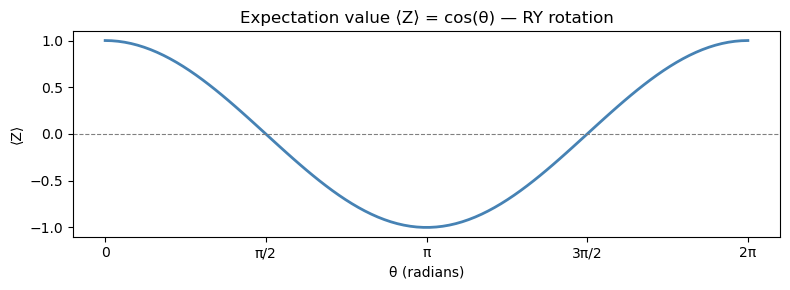

In [9]:
dev1 = qml.device('default.qubit', wires=1)

@qml.qnode(dev1)
def single_qubit(theta):
    """Rotate around Y axis and measure Z expectation."""
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

# Sweep theta from 0 to 2π
thetas = np.linspace(0, 2 * np.pi, 100)
expvals = [single_qubit(t) for t in thetas]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(thetas, expvals, lw=2, color='steelblue')
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_xlabel('θ (radians)'); ax.set_ylabel('⟨Z⟩')
ax.set_title('Expectation value ⟨Z⟩ = cos(θ) — RY rotation')
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
plt.tight_layout(); plt.savefig('ry_sweep.png', dpi=80); plt.show()

### 6c. Quantum Gradients — Parameter Shift Rule

The **parameter shift rule** computes exact gradients of quantum circuits without finite differences:

$$\frac{\partial}{\partial \theta_k} \langle O \rangle = \frac{1}{2}\left[ \langle O \rangle_{\theta_k + \pi/2} - \langle O \rangle_{\theta_k - \pi/2} \right]$$

PennyLane's `qml.grad` applies this automatically.  

> **Critical:** Use `pennylane.numpy` (aliased as `pnp`) or pass `requires_grad=True` to tell PennyLane which parameters are trainable. Standard NumPy arrays are treated as **non-differentiable constants** and will silently return zero gradients.

In [10]:
import pennylane.numpy as pnp   # PennyLane-aware NumPy

dev4 = qml.device('default.qubit', wires=4)

@qml.qnode(dev4)
def variational_circuit(params):
    """4-qubit variational circuit."""
    for i in range(4):
        qml.RY(params[i], wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(3))

# requires_grad=True tells PennyLane these are trainable parameters
params = pnp.array([0.1, 0.5, 1.2, 0.8], requires_grad=True)

grad_fn = qml.grad(variational_circuit)
gradients = grad_fn(params)

print('Parameters :', params)
print('Gradients  :', np.round(gradients, 4))
print('\nNote: gradient of PauliZ⊗PauliZ = -sin(θ_0)·cos(θ_3) for qubit 0')

# Verify parameter shift manually for param 0
shift = np.pi / 2
p_plus  = pnp.array([params[0]+shift, params[1], params[2], params[3]], requires_grad=False)
p_minus = pnp.array([params[0]-shift, params[1], params[2], params[3]], requires_grad=False)
grad_manual = 0.5 * (variational_circuit(p_plus) - variational_circuit(p_minus))
print(f'\nManual parameter-shift grad[0]: {grad_manual:.6f}')
print(f'qml.grad result    grad[0]: {gradients[0]:.6f}')
print(f'Match: {abs(grad_manual - gradients[0]) < 1e-8}')

Parameters : [0.1 0.5 1.2 0.8]
Gradients  : [-0.     -0.121  -0.5699 -0.2281]

Note: gradient of PauliZ⊗PauliZ = -sin(θ_0)·cos(θ_3) for qubit 0

Manual parameter-shift grad[0]: -0.000000
qml.grad result    grad[0]: -0.000000
Match: True


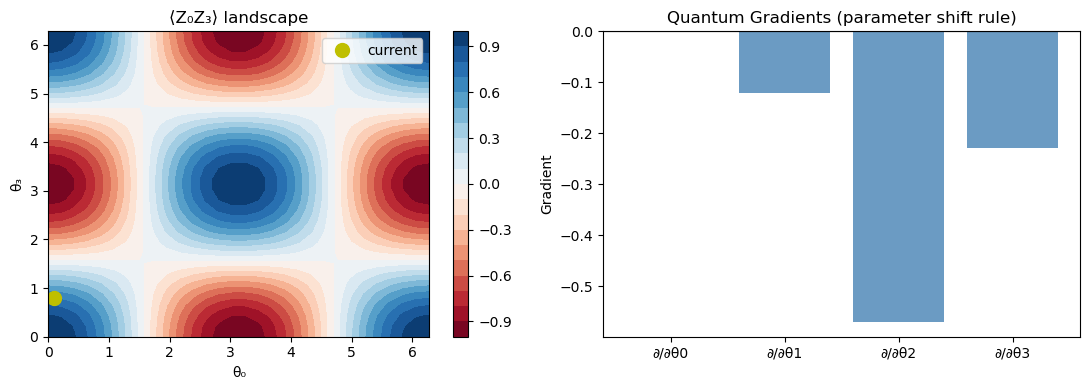

In [11]:
# ── Gradient visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: gradient landscape for param 0 vs param 3
th0_vals = np.linspace(0, 2*np.pi, 30)
th3_vals = np.linspace(0, 2*np.pi, 30)
TH0, TH3 = np.meshgrid(th0_vals, th3_vals)
EXP = np.cos(TH0) * np.cos(TH3)  # analytic form of ⟨Z0Z3⟩

im = axes[0].contourf(TH0, TH3, EXP, levels=20, cmap='RdBu')
plt.colorbar(im, ax=axes[0])
axes[0].set_xlabel('θ₀'); axes[0].set_ylabel('θ₃')
axes[0].set_title('⟨Z₀Z₃⟩ landscape')
axes[0].plot([params[0]], [params[3]], 'yo', ms=10, label='current')
axes[0].legend()

# Right: gradients as bar chart
axes[1].bar([f'∂/∂θ{i}' for i in range(4)], gradients, color='steelblue', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Gradient')
axes[1].set_title('Quantum Gradients (parameter shift rule)')

plt.tight_layout()
plt.savefig('gradients.png', dpi=80)
plt.show()

---
## 7. Mini Variational Quantum Circuit (VQC) Training

We train a small VQC to approximate a target expectation value — a toy version of the inner training loop used in VQE and QAOA.

Goal: minimise $\langle Z \rangle$, i.e. drive the qubit toward $\lvert 1 \rangle$ (where $\langle Z \rangle = -1$).

Step   0 | ⟨Z⟩ = 0.9752
Step  20 | ⟨Z⟩ = 0.0638
Step  40 | ⟨Z⟩ = -0.9615
Step  60 | ⟨Z⟩ = -0.9982

Final ⟨Z⟩ = -0.9995  (target: -1.0)


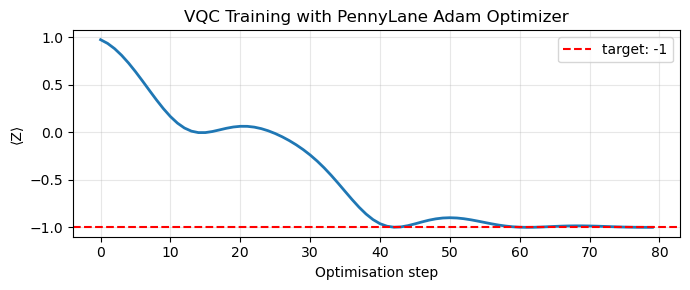

In [12]:
dev_train = qml.device('default.qubit', wires=2)

@qml.qnode(dev_train, diff_method='parameter-shift')
def vqc(params):
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=1)
    return qml.expval(qml.PauliZ(0))

# Initialise with pennylane.numpy to enable autograd
params_vqc = pnp.array([0.1, 0.2, 0.3], requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

cost_history = []
for step in range(80):
    params_vqc, cost = opt.step_and_cost(vqc, params_vqc)
    cost_history.append(float(cost))
    if step % 20 == 0:
        print(f'Step {step:3d} | ⟨Z⟩ = {float(cost):.4f}')

print(f'\nFinal ⟨Z⟩ = {cost_history[-1]:.4f}  (target: -1.0)')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(cost_history, lw=2)
ax.axhline(-1.0, ls='--', color='red', label='target: -1')
ax.set_xlabel('Optimisation step'); ax.set_ylabel('⟨Z⟩')
ax.set_title('VQC Training with PennyLane Adam Optimizer')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('vqc_training.png', dpi=80); plt.show()

---
## 8. Summary & Key Takeaways

| Concept | What you learned |
|---------|------------------|
| $\lvert 0 \rangle$, $\lvert 1 \rangle$ | Column vectors $(1,0)^\mathsf{T}$, $(0,1)^\mathsf{T}$; Born rule |
| Multi-qubit bases | Tensor products and bit ordering (e.g. `np.kron`) |
| Qubits | 2-dimensional complex unit vector; $2^n$-dimensional joint space |
| Quantum gates | Unitary matrices — reversible, differentiable |
| Entanglement | Correlations that cannot be explained classically |
| PennyLane QNode | Differentiable wrapper around a quantum circuit |
| Parameter shift | Exact gradient rule — no finite differences |
| `pennylane.numpy` | Required for `requires_grad=True` |

**Next:** Notebook 2 starts with encoding prerequisites, then builds hybrid quantum-classical models.

---

### Grover and Shor at headline level

**Grover.** Amplitude amplification drives probability mass toward marked basis states using repeated oracle + diffusion steps; idealised query complexity scales as $O(\sqrt{N})$ for $N$ unstructured items.

**Shor.** Period finding for modular exponentials feeds classical post-processing for factoring; requires substantial coherent depth for interesting instances.

**Limitations.** Depth, gate noise, and subleading constants matter on hardware; prefer simulators for pedagogy unless you explicitly budget shots and noise models.

Small simulator examples with $n=2$ or $n=3$ qubits are enough to see the mechanism; they are not evidence for business-scale speedup.
